# Hourly Energy Consumption — Minimal Time‑Series Forecast (Per Region)

Овaa скрипта е **едноставен и стабилен** пример за краткорочно предвидување на потрошувачка на електрична енергија по региони (PJM).  
Структура: вчитување → ЕДА → feature engineering (календар + лагови/ролинг) → модел (Ridge) **по регион** → walk‑forward валидација со `TimeSeriesSplit` → baseline споредба (наивен 24h/168h) → графици.

> **Напомена:** Стави ги CSV фајловите во папка `./data` или промени ја патеката во променливата `DATA_DIR`.


In [1]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 4)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
import kagglehub


path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")

print("Path to dataset files:", path)

100%|██████████| 11.4M/11.4M [00:00<00:00, 165MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3


In [4]:
DATA_DIR = '/root/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3'
paths = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
if not paths:
    raise FileNotFoundError('No CSVs found. Put the dataset CSVs into ./data or update DATA_DIR.')

def tidy_one_csv(p):
    d = pd.read_csv(p)
    d.columns = [c.strip().replace(' ', '_') for c in d.columns]
    if 'Datetime' not in d.columns and 'datetime' in d.columns:
        d.rename(columns={'datetime':'Datetime'}, inplace=True)
    if {'Datetime','MW','Region'}.issubset(d.columns):
        out = d[['Datetime','MW','Region']].copy()
    else:
        if 'Datetime' not in d.columns:
            raise ValueError(f"Missing 'Datetime' in {p}: {d.columns.tolist()}")
        value_cols = [c for c in d.columns if c != 'Datetime']
        non_null_cols = [c for c in value_cols if d[c].notna().any()]
        if not non_null_cols:
            raise ValueError(f"No usable value columns in {p}")
        out = d.melt(id_vars='Datetime', value_vars=non_null_cols,
                     var_name='Region', value_name='MW')
    out['Datetime'] = pd.to_datetime(out['Datetime'])
    out = out[~out['Region'].isin(['PJME','PJMW','PJM_Load'])].reset_index(drop=True)
    out['MW'] = pd.to_numeric(out['MW'], errors='coerce')
    out = out.dropna(subset=['MW'])
    return out[['Datetime','MW','Region']]

dfs = [tidy_one_csv(p) for p in paths]
df_all = (pd.concat(dfs, ignore_index=True)
            .drop_duplicates()
            .sort_values(['Region','Datetime'])
            .reset_index(drop=True))

print("Regions (sample):", sorted(df_all['Region'].unique())[:10], "…")
print("Shape:", df_all.shape)
df_all.head()


Regions (sample): ['AEP', 'AEP_MW', 'COMED', 'COMED_MW', 'DAYTON', 'DAYTON_MW', 'DEOK', 'DEOK_MW', 'DOM', 'DOM_MW'] …
Shape: (1858866, 3)


,Datetime,MW,Region
0,2004-10-01 01:00:00,12379.0,AEP
1,2004-10-01 02:00:00,11935.0,AEP
2,2004-10-01 03:00:00,11692.0,AEP
3,2004-10-01 04:00:00,11597.0,AEP
4,2004-10-01 05:00:00,11681.0,AEP


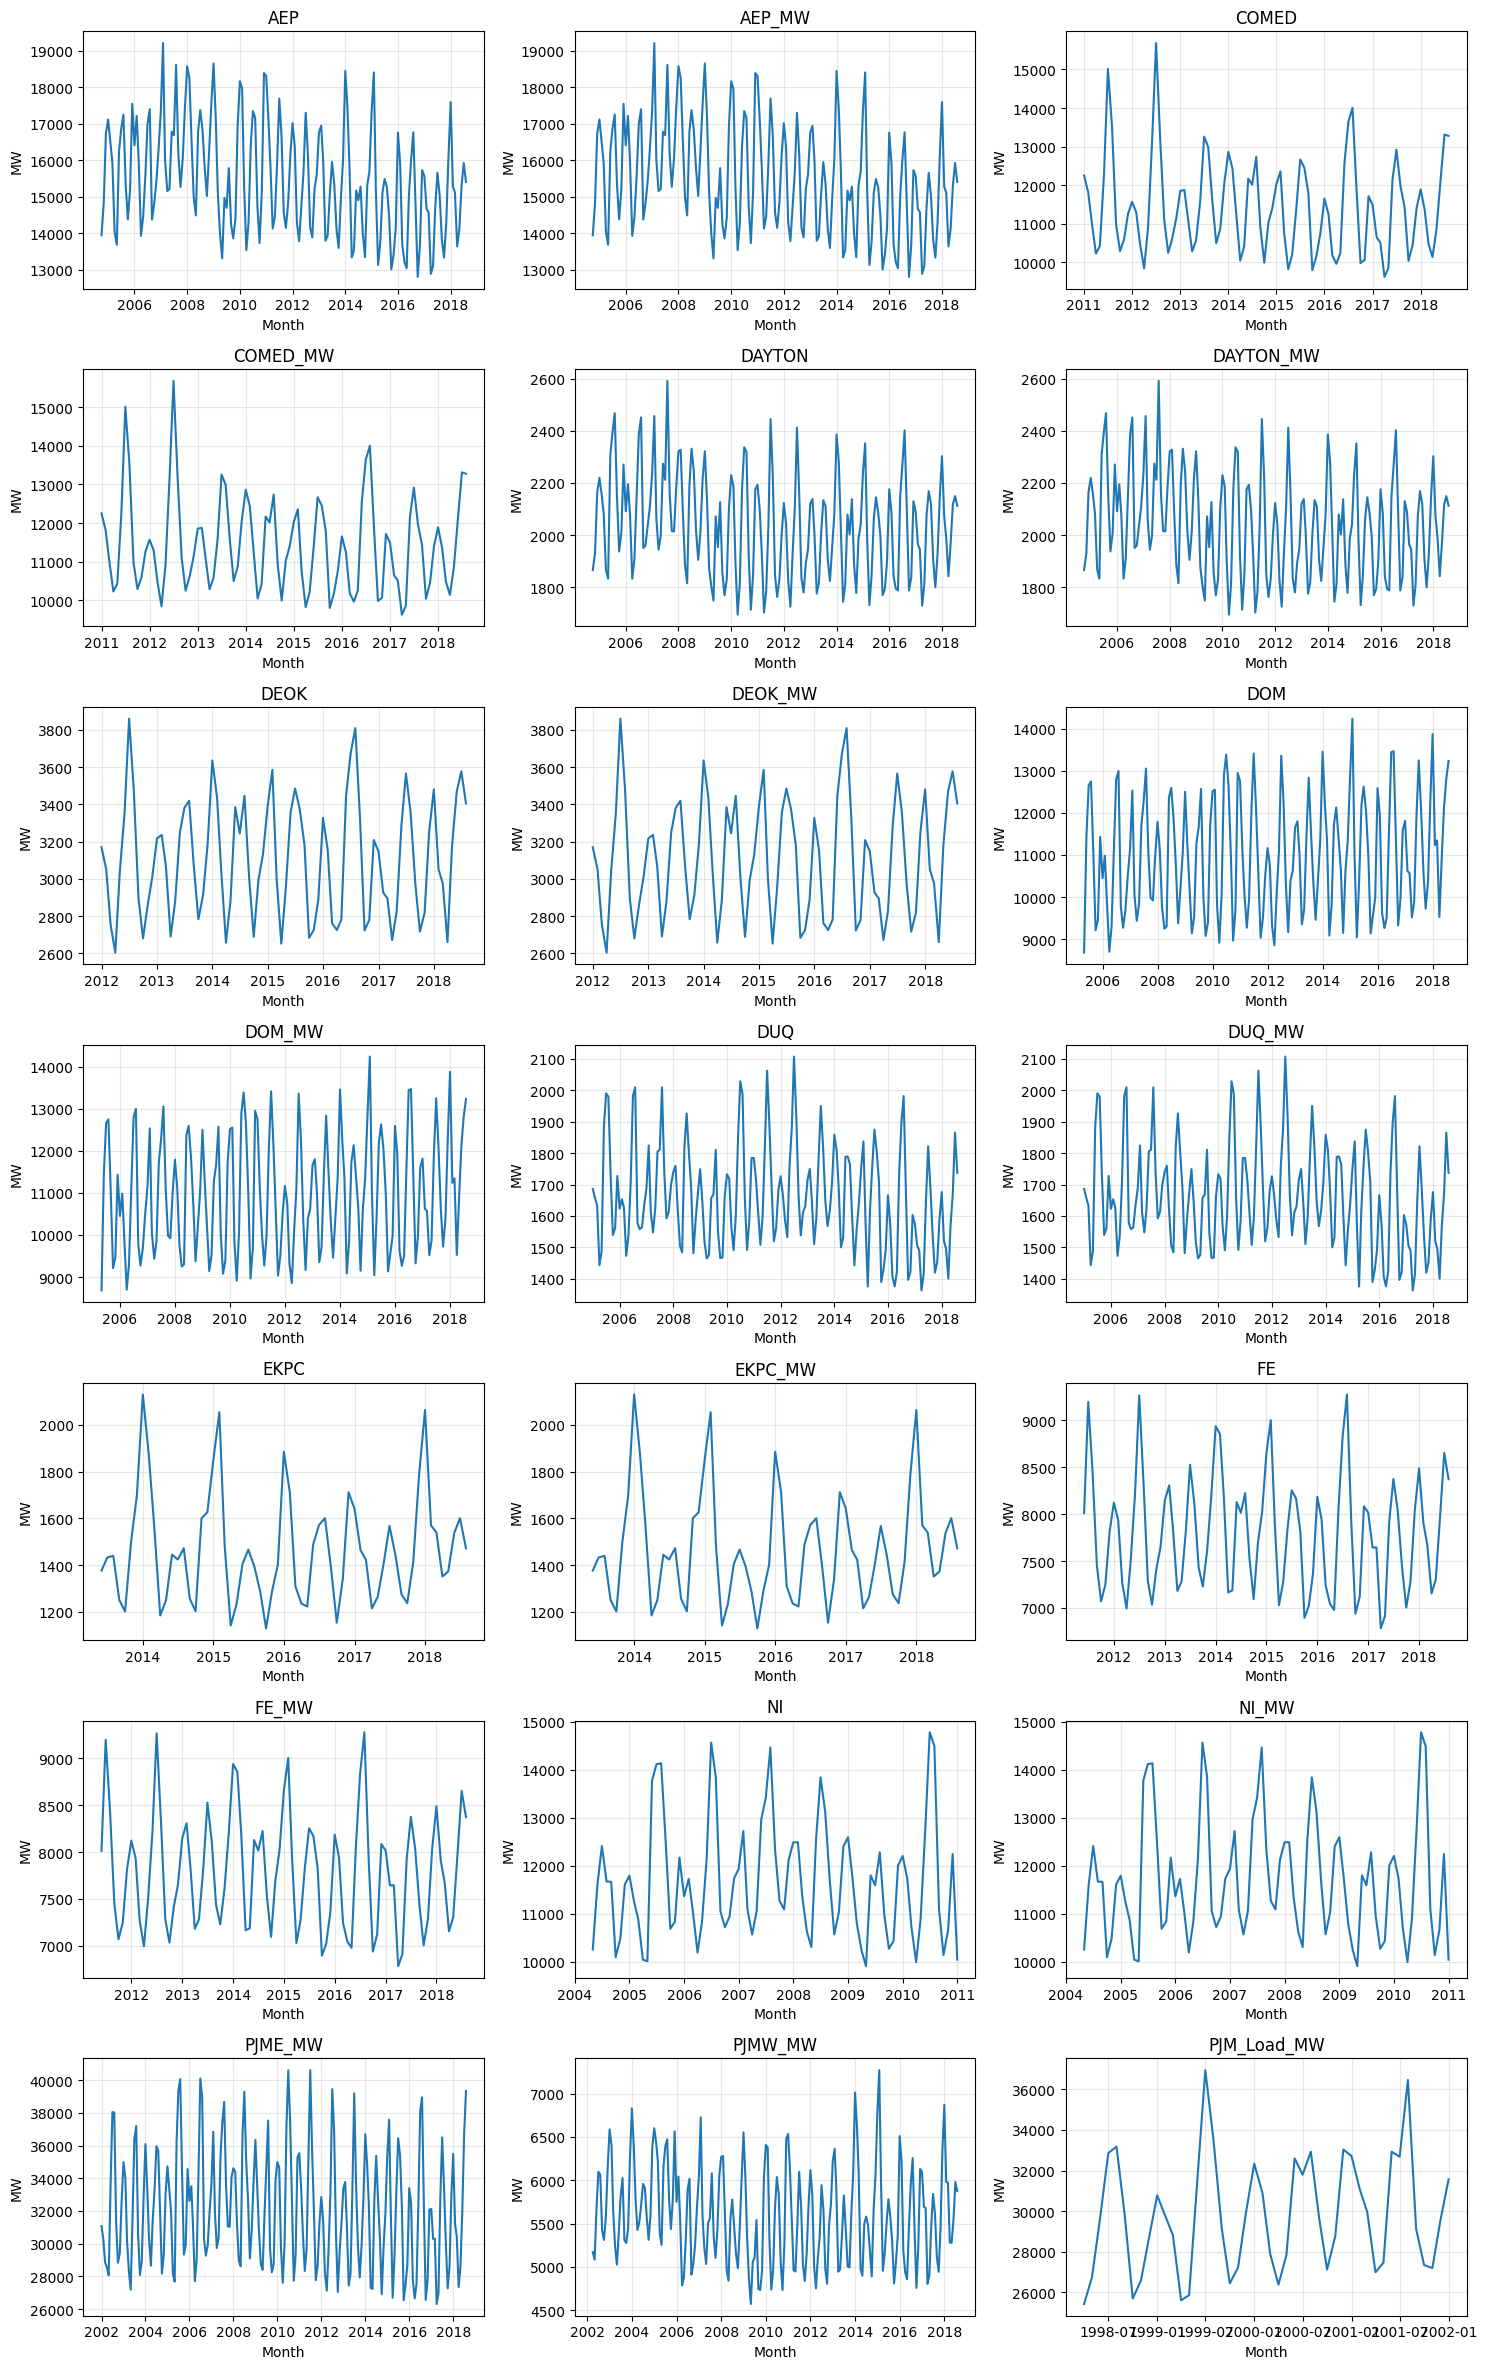

In [5]:
tmp = (df_all
       .assign(month=df_all['Datetime'].dt.to_period('M'))
       .groupby(['Region','month'], as_index=False)['MW'].mean())
tmp['month'] = tmp['month'].dt.to_timestamp()

regions = tmp['Region'].unique()
n, ncols = len(regions), 3
nrows = math.ceil(n/ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.4*nrows))
axes = axes.ravel()

for i, r in enumerate(regions):
    ax = axes[i]
    d = tmp[tmp['Region'] == r]
    ax.plot(d['month'], d['MW'])
    ax.set_title(r)
    ax.set_xlabel('Month')
    ax.set_ylabel('MW')
    ax.grid(alpha=.3)

for j in range(i+1, nrows*ncols):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [6]:
def add_calendar_features(d):
    d = d.copy()
    dt = d['Datetime']
    d['year']  = dt.dt.year
    d['month'] = dt.dt.month
    d['day']   = dt.dt.day
    d['hour']  = dt.dt.hour
    d['dow']   = dt.dt.dayofweek
    d['is_weekend'] = (d['dow'] >= 5).astype(int)
    d['hour_sin']  = np.sin(2*np.pi * d['hour']  / 24)
    d['hour_cos']  = np.cos(2*np.pi * d['hour']  / 24)
    d['month_sin'] = np.sin(2*np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2*np.pi * d['month'] / 12)
    return d

df_all = add_calendar_features(df_all)
df_all.head()

,Datetime,MW,Region,year,month,day,hour,dow,is_weekend,hour_sin,hour_cos,month_sin,month_cos
0,2004-10-01 01:00:00,12379.0,AEP,2004,10,1,1,4,0,0.258819,0.965926,-0.866025,0.5
1,2004-10-01 02:00:00,11935.0,AEP,2004,10,1,2,4,0,0.500000,0.866025,-0.866025,0.5
2,2004-10-01 03:00:00,11692.0,AEP,2004,10,1,3,4,0,0.707107,0.707107,-0.866025,0.5
3,2004-10-01 04:00:00,11597.0,AEP,2004,10,1,4,4,0,0.866025,0.500000,-0.866025,0.5
4,2004-10-01 05:00:00,11681.0,AEP,2004,10,1,5,4,0,0.965926,0.258819,-0.866025,0.5


In [7]:
def add_ts_features_per_region(d):
    d = d.sort_values(['Region','Datetime']).copy()
    def _per_region(g):
        g = g.copy()
        g['MW_lag1']   = g['MW'].shift(1)
        g['MW_lag24']  = g['MW'].shift(24)
        g['MW_lag168'] = g['MW'].shift(168)
        g['roll24']    = g['MW'].rolling(24).mean()
        g['roll168']   = g['MW'].rolling(168).mean()
        return g
    d = d.groupby('Region', group_keys=False).apply(_per_region)
    d = d.dropna().reset_index(drop=True)
    return d

df_all = add_ts_features_per_region(df_all)
df_all.head()

/tmp/ipython-input-383387447.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  d = d.groupby('Region', group_keys=False).apply(_per_region)


,Datetime,MW,Region,year,month,day,hour,dow,is_weekend,hour_sin,hour_cos,month_sin,month_cos,MW_lag1,MW_lag24,MW_lag168,roll24,roll168
0,2004-10-08 01:00:00,12468.0,AEP,2004,10,8,1,4,0,0.258819,0.965926,-0.866025,0.5,13271.0,12484.0,12379.0,14449.666667,13870.845238
1,2004-10-08 02:00:00,12046.0,AEP,2004,10,8,2,4,0,0.500000,0.866025,-0.866025,0.5,12468.0,12054.0,11935.0,14449.333333,13871.505952
2,2004-10-08 03:00:00,11749.0,AEP,2004,10,8,3,4,0,0.707107,0.707107,-0.866025,0.5,12046.0,11745.0,11692.0,14449.500000,13871.845238
3,2004-10-08 04:00:00,11784.0,AEP,2004,10,8,4,4,0,0.866025,0.500000,-0.866025,0.5,11749.0,11757.0,11597.0,14450.625000,13872.958333
4,2004-10-08 05:00:00,11919.0,AEP,2004,10,8,5,4,0,0.965926,0.258819,-0.866025,0.5,11784.0,12041.0,11681.0,14445.541667,13874.375000


In [8]:
REGION = 'AEP'
df_reg = df_all[df_all['Region'] == REGION].copy().reset_index(drop=True)

drop_cols = ['Region','Datetime']
target = 'MW'
feature_cols = [c for c in df_reg.columns if c not in drop_cols + [target]]

X = df_reg[feature_cols]
y = df_reg[target]

X.shape, y.shape

((121105, 15), (121105,))

In [10]:
def seasonal_naive(series, lag):
    return series.shift(lag)

def evaluate_fold(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - ss_res/ss_tot if ss_tot != 0 else 0.0
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}


tscv = TimeSeriesSplit(n_splits=5)
rows = []

model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

last_fold = None

for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    Xtr, Xte = X.iloc[tr], X.iloc[te]
    ytr, yte = y.iloc[tr], y.iloc[te]

    model.fit(Xtr, ytr)
    pred = model.predict(Xte)

    base24_full  = seasonal_naive(y, 24)
    base168_full = seasonal_naive(y, 168)
    base24  = base24_full.iloc[te]
    base168 = base168_full.iloc[te]

    msk = (~base24.isna()) & (~base168.isna())
    y_eval    = yte[msk]
    pred_eval = pd.Series(pred, index=yte.index)[msk]
    b24_eval  = base24[msk]
    b168_eval = base168[msk]

    met_model = evaluate_fold(y_eval, pred_eval)
    met_b24   = evaluate_fold(y_eval, b24_eval)
    met_b168  = evaluate_fold(y_eval, b168_eval)

    rows.append({
        'fold': fold,
        'n_test': len(y_eval),
        'Model_RMSE': met_model['RMSE'],
        'Model_MAE':  met_model['MAE'],
        'Model_R2':   met_model['R2'],
        'Naive24_RMSE': met_b24['RMSE'],
        'Naive168_RMSE': met_b168['RMSE'],
        'Model_vs_Naive24_%': 100.0 * (met_b24['RMSE']  - met_model['RMSE'])  / met_b24['RMSE'],
        'Model_vs_Naive168_%':100.0 * (met_b168['RMSE'] - met_model['RMSE']) / met_b168['RMSE'],
    })

    last_fold = (y_eval, pred_eval)

report = pd.DataFrame(rows)
report

,fold,n_test,Model_RMSE,Model_MAE,Model_R2,Naive24_RMSE,Naive168_RMSE,Model_vs_Naive24_%,Model_vs_Naive168_%
0,1,20184,458.043452,351.169599,0.970157,1421.367992,1935.118574,67.774464,76.329954
1,2,20184,414.299867,323.407980,0.975920,1235.632455,1663.479044,66.470623,75.094374
2,3,20184,417.579582,324.036115,0.967974,1277.758147,1730.474623,67.319357,75.869072
3,4,20184,422.899595,328.433851,0.972789,1349.698077,1919.087167,68.667097,77.963503
4,5,20184,391.382648,306.851745,0.975337,1214.519087,1875.702804,67.774681,79.134080


In [11]:
summary = (report
           .drop(columns=['fold'])
           .agg(['mean','std'])
           .T)

print('Region:', REGION)
print('\nPer-fold metrics:')
display(report)

print('\nSummary (mean/std):')
display(summary)

Region: AEP

Per-fold metrics:


,fold,n_test,Model_RMSE,Model_MAE,Model_R2,Naive24_RMSE,Naive168_RMSE,Model_vs_Naive24_%,Model_vs_Naive168_%
0,1,20184,458.043452,351.169599,0.970157,1421.367992,1935.118574,67.774464,76.329954
1,2,20184,414.299867,323.407980,0.975920,1235.632455,1663.479044,66.470623,75.094374
2,3,20184,417.579582,324.036115,0.967974,1277.758147,1730.474623,67.319357,75.869072
3,4,20184,422.899595,328.433851,0.972789,1349.698077,1919.087167,68.667097,77.963503
4,5,20184,391.382648,306.851745,0.975337,1214.519087,1875.702804,67.774681,79.134080



Summary (mean/std):


,mean,std
n_test,20184.000000,0.000000
Model_RMSE,420.841029,24.028514
Model_MAE,326.779858,15.918720
Model_R2,0.972435,0.003383
Naive24_RMSE,1299.795152,85.359162
Naive168_RMSE,1824.772442,121.009377
Model_vs_Naive24_%,67.601244,0.799045
Model_vs_Naive168_%,76.878197,1.640718


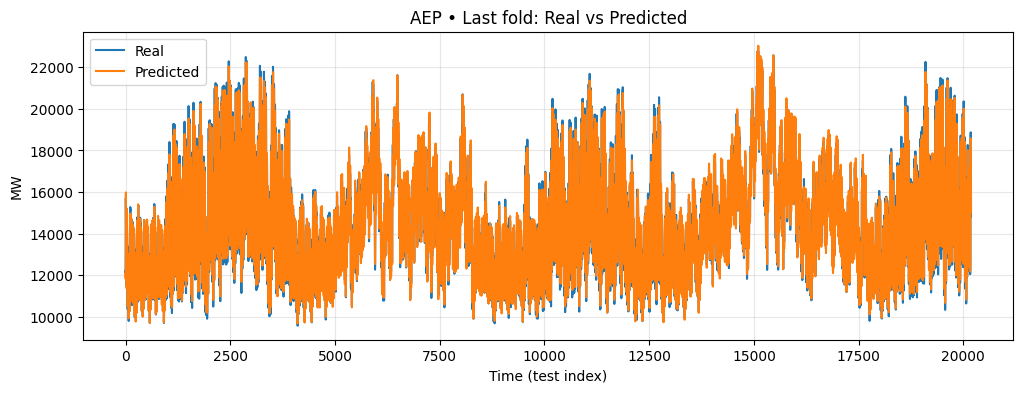

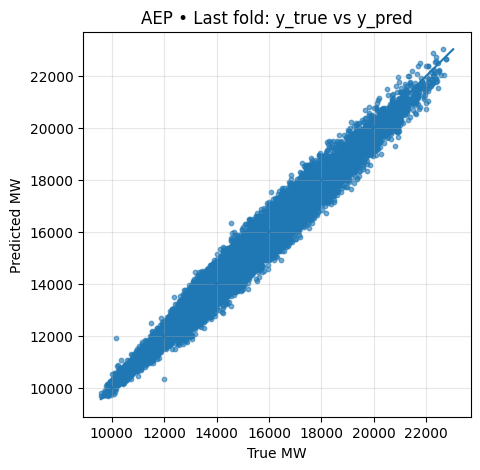

In [12]:
y_eval, pred_eval = last_fold

plt.figure(figsize=(12,4))
plt.plot(y_eval.values, label='Real')
plt.plot(pred_eval.values, label='Predicted')
plt.title(f'{REGION} • Last fold: Real vs Predicted')
plt.xlabel('Time (test index)')
plt.ylabel('MW')
plt.legend()
plt.grid(alpha=.3)
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(y_eval.values, pred_eval.values, s=10, alpha=0.6)
lims = [min(y_eval.min(), pred_eval.min()), max(y_eval.max(), pred_eval.max())]
plt.plot(lims, lims)
plt.title(f'{REGION} • Last fold: y_true vs y_pred')
plt.xlabel('True MW')
plt.ylabel('Predicted MW')
plt.grid(alpha=.3)
plt.show()